In [2]:
# ── Mount Google Drive & add project root to sys.path ──
from google.colab import drive
drive.mount("/content/drive")

import os, sys
PROJECT_ROOT = "/content/drive/MyDrive/690AB/flash-attention"   # ← adjust if your Drive path differs
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

RESULTS_DIR = os.path.join(PROJECT_ROOT, "results", "triton_attn")
os.makedirs(RESULTS_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Reusable timing / roofline / plotting utilities live in utils/.
from utils.timing import benchmark_torch as benchmark, peak_memory_mb_torch as peak_memory_mb, cuda_event_time_ms
from utils.roofline import (
    ridge_point,
    theoretical_flops,
    theoretical_bytes_naive,
    theoretical_bytes_flash,
    L4_PEAK_TFLOPS,
    L4_PEAK_BW_GBS,
)
from utils.plotting import (
    plot_roofline_scatter_single,
    plot_roofline_trajectory_and_efficiency,
    plot_fwd_benchmark,
    plot_bwd_benchmark,
)


# FlashAttention — A Full Systems Implementation
*From Naive Attention to IO-Aware Forward & Backward Passes, with Roofline Analysis*

---

This notebook implements FlashAttention from scratch using Triton, benchmarks it against PyTorch's reference implementation, and analyzes performance using the roofline model. The implementation follows Dao et al. (2022), building the kernel incrementally across five steps before extending it to a full forward+backward pass.

**Pipeline overview:**
1. Reference attention baseline (PyTorch)
2. FlashAttention forward kernel (Triton) — built step-by-step
3. Forward pass benchmarks: runtime & memory across sequence lengths
4. FlashAttention backward pass with recomputation
5. Systems profiling: roofline analysis, arithmetic intensity, SM occupancy
6. In-notebook hardware profiling via `torch.profiler`

### GPU Check

In [4]:
!nvidia-smi

Thu Apr 30 21:23:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   49C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Installing Dependencies and Importing Libraries

In [5]:
!pip install -q torch torchvision torchaudio
!pip install -q triton

In [6]:
import gc
import math
import torch
import triton
import triton.language as tl
import pandas as pd

In [7]:
assert torch.cuda.is_available(), "CUDA GPU required"
device = "cuda"

torch.manual_seed(0)

B = 1          # batch
H = 4          # heads
N = 1024        # sequence length
D = 128         # head dimension

dtype = torch.float16 # FP16
# dummy input tensors representing attention inputs-
q = torch.randn(B, H, N, D, device=device, dtype=dtype)
k = torch.randn(B, H, N, D, device=device, dtype=dtype)
v = torch.randn(B, H, N, D, device=device, dtype=dtype)

---
## 1. Reference Attention

The standard scaled dot-product attention algorithm:

1. Compute similarity scores $S = QK^T$
2. Scale to stabilize gradients $S = S / \sqrt{D}$
3. Apply softmax to get attention weights $P = \text{softmax}(S)$
4. Weighted sum of values $O = PV$

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{D}}\right)V$$

We implement both a manual version (for pedagogical clarity) and PyTorch's built-in `scaled_dot_product_attention` as a sanity check. The manual version serves as our correctness reference throughout.

In [8]:
def reference_attention(q, k, v):
    scale = 1.0 / math.sqrt(q.shape[-1])
    scores = torch.matmul(q, k.transpose(-1, -2)) * scale
    probs = torch.softmax(scores, dim=-1)
    return torch.matmul(probs, v)

# Sanity check
out_ref = reference_attention(q, k, v)
print(f"Output shape: {out_ref.shape}  dtype: {out_ref.dtype}")

t_ref, _ = benchmark(reference_attention, q, k, v)
print(f"Reference attention time: {t_ref*1e3:.3f} ms")

Output shape: torch.Size([1, 4, 1024, 128])  dtype: torch.float16
Reference attention time: 0.092 ms


---
## 2. FlashAttention Forward Kernel

Before FlashAttention, PyTorch materializes the full $N \times N$ score matrix in HBM:
1. Load $Q$ and $K$ from HBM → compute $S = QK^T$ → write $N \times N$ matrix back to HBM
2. Read $S$ from HBM → compute softmax → write $P$ back to HBM
3. Read $P$ from HBM → compute $PV$ → write output to HBM

FlashAttention's key insight is **tiled online softmax**: process attention in blocks that fit in SRAM, maintaining running statistics that allow exact softmax computation without ever materializing the full $N \times N$ matrix.

**Memory savings:**
- *Memory reuse* — each $Q$ tile is reused across all $K$/$V$ blocks without HBM round-trips
- *Arithmetic intensity* — all intermediate math lives in SRAM; only the final output goes to HBM

We build the kernel across five steps, verifying each one before proceeding.

### Step 1 — Grid & Tiling Scaffold

Verify the kernel launch grid before adding any math. Each Triton program handles one `[BLOCK_M, D]` tile of the output.

In [9]:
# Step 1: Kernel scaffold (verify grid)
@triton.jit
def flash_attn_fwd_v1(
    Q_ptr,
    stride_qb, stride_qh, stride_qn, stride_qd,
    N, D,
    BLOCK_M: tl.constexpr,
    BLOCK_D: tl.constexpr,
):
    pid_m  = tl.program_id(0)   # which Q-tile am I?
    pid_bh = tl.program_id(1)   # which (batch × head)?
    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)

def flash_v1_test(q, k, v, block_m=64):
    B, H, N, D = q.shape
    grid = (triton.cdiv(N, block_m), B * H)
    print(f"Grid: {grid}  →  {grid[0]*grid[1]} total programs")
    # N=128, B=1, H=4  →  expect Grid: (2, 4) → 8 programs
    flash_attn_fwd_v1[grid](
        q,
        q.stride(0), q.stride(1), q.stride(2), q.stride(3),
        N=N, D=D, BLOCK_M=block_m, BLOCK_D=D,
    )

flash_v1_test(q, k, v)

Grid: (16, 4)  →  64 total programs


### Step 2 — Load Q Tile from HBM → SRAM

Build 2D pointer arithmetic to load one `[BLOCK_M, D]` slice of $Q$ into registers. The boundary mask handles the last tile when $N$ is not a multiple of `BLOCK_M`.

In [10]:
# Step 2 — Load Q tile
@triton.jit
def flash_attn_fwd_v2(
    Q_ptr,
    stride_qh, stride_qn, stride_qd,
    N, D,
    BLOCK_M: tl.constexpr,
    BLOCK_D: tl.constexpr,
):
    pid_m  = tl.program_id(0)
    pid_bh = tl.program_id(1)

    # Move base pointer to this (batch, head)
    Q_bh = Q_ptr + pid_bh * stride_qh

    # Row and dim offsets for this tile
    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)  # [BLOCK_M] — absolute row indices
    offs_d = tl.arange(0, BLOCK_D)                     # [BLOCK_D] — head dim indices

    # Build 2D pointer grid: each entry points to one element of Q
    q_ptrs = Q_bh + offs_m[:, None] * stride_qn \
                  + offs_d[None, :] * stride_qd   # shape [BLOCK_M, BLOCK_D]

    # Mask needed: last tile may have rows beyond N
    q_mask = offs_m[:, None] < N
    q = tl.load(q_ptrs, mask=q_mask, other=0.0)   # loaded into SRAM

def flash_v2_test(q, k, v, block_m=64):
    B, H, N, D = q.shape
    grid = (triton.cdiv(N, block_m), B * H)
    flash_attn_fwd_v2[grid](
        q,
        q.stride(1), q.stride(2), q.stride(3),
        N=N, D=D, BLOCK_M=block_m, BLOCK_D=D,
    )
    print(f"Q tile loaded into SRAM: shape [{block_m}, {D}]")
    print(f"Each of {grid[0]*grid[1]} programs loaded its own tile independently")

flash_v2_test(q, k, v)

Q tile loaded into SRAM: shape [64, 128]
Each of 64 programs loaded its own tile independently


### Step 3 — Inner Loop: Load K/V Tiles and Compute Score Tiles

Slide a `BLOCK_N` window across the full sequence, loading $K$ transposed (`[D, BLOCK_N]`) so that `tl.dot(q, k)` yields the `[BLOCK_M, BLOCK_N]` score tile directly.

In [11]:
# Step 3 — Inner loop, load K/V tiles, compute scores

@triton.jit
def flash_attn_fwd_v3(
    Q_ptr, K_ptr, V_ptr,
    stride_qh, stride_qn, stride_qd,
    stride_kh, stride_kn, stride_kd,
    stride_vh, stride_vn, stride_vd,
    N, D, scale,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_D: tl.constexpr,
):
    pid_m  = tl.program_id(0)
    pid_bh = tl.program_id(1)

    Q_bh = Q_ptr + pid_bh * stride_qh
    K_bh = K_ptr + pid_bh * stride_kh
    V_bh = V_ptr + pid_bh * stride_vh

    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_d = tl.arange(0, BLOCK_D)

    # Load Q tile — same as Step 2
    q = tl.load(Q_bh + offs_m[:, None] * stride_qn + offs_d[None, :] * stride_qd,
                mask=offs_m[:, None] < N, other=0.0)  # [BLOCK_M, D]

    # Inner loop: slide a BLOCK_N window across the full sequence
    for start_n in range(0, N, BLOCK_N):
        offs_n = start_n + tl.arange(0, BLOCK_N)

        # K loaded TRANSPOSED: [D, BLOCK_N]
        # so tl.dot(q, k) → [BLOCK_M, BLOCK_N]  (the score tile)
        k = tl.load(K_bh + offs_n[None, :] * stride_kn + offs_d[:, None] * stride_kd,
                    mask=offs_n[None, :] < N, other=0.0)   # [D, BLOCK_N]

        s = tl.dot(q, k) * scale                           # [BLOCK_M, BLOCK_N]
        s = tl.where(offs_n[None, :] < N, s, float("-inf")) # mask padding cols

        # V tile: [BLOCK_N, D]  — loaded normally, not transposed
        v = tl.load(V_bh + offs_n[:, None] * stride_vn + offs_d[None, :] * stride_vd,
                    mask=offs_n[:, None] < N, other=0.0)   # [BLOCK_N, D]

        # s and v are ready — softmax + accumulation comes in Step 4

def flash_v3_test(q, k, v, block_m=64, block_n=64):
    B, H, N, D = q.shape
    scale = 1.0 / math.sqrt(D)
    grid  = (triton.cdiv(N, block_m), B * H)
    flash_attn_fwd_v3[grid](
        q, k, v,
        q.stride(1), q.stride(2), q.stride(3),
        k.stride(1), k.stride(2), k.stride(3),
        v.stride(1), v.stride(2), v.stride(3),
        N=N, D=D, scale=scale,
        BLOCK_M=block_m, BLOCK_N=block_n, BLOCK_D=D,
    )
    n_tiles = N // block_n
    print(f"Inner loop: {n_tiles} K/V tile(s) per Q-tile")
    print(f"Score tile shape each iteration: [{block_m}, {block_n}]")
    print(f"K loaded transposed [D, BLOCK_N], V loaded normal [BLOCK_N, D] ")

flash_v3_test(q, k, v)

Inner loop: 16 K/V tile(s) per Q-tile
Score tile shape each iteration: [64, 64]
K loaded transposed [D, BLOCK_N], V loaded normal [BLOCK_N, D] 


### Step 4 — Online Softmax Accumulators

Normally softmax requires the full row to compute $\exp(x - \max(x))$. The online version maintains three accumulators updated tile-by-tile:

| Accumulator | Shape | Meaning |
|---|---|---|
| `m_i` | `[BLOCK_M]` | Running row maximum |
| `l_i` | `[BLOCK_M]` | Running normalisation sum |
| `acc` | `[BLOCK_M, D]` | Running weighted value sum |

When a new tile reveals a larger maximum $m_{\text{new}}$, the existing accumulator is rescaled by $\alpha = \exp(m_i - m_{\text{new}}) \leq 1$ before folding in the new tile — this is the **correction** that makes online softmax exact.

In [12]:
# Step 4 — Online softmax accumulators ──────────────────
# Key idea: normally softmax needs the full row to compute exp(x - max(x))
# Online version maintains running m (max) and l (sum) so we can
# process one tile at a time and CORRECT past accumulations on the fly

@triton.jit
def _flash_attn_fwd_v4(
    Q_ptr, K_ptr, V_ptr,
    stride_qh, stride_qn, stride_qd,
    stride_kh, stride_kn, stride_kd,
    stride_vh, stride_vn, stride_vd,
    N, D, scale,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_D: tl.constexpr,
):
    pid_m  = tl.program_id(0)
    pid_bh = tl.program_id(1)

    Q_bh = Q_ptr + pid_bh * stride_qh
    K_bh = K_ptr + pid_bh * stride_kh
    V_bh = V_ptr + pid_bh * stride_vh

    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_d = tl.arange(0, BLOCK_D)

    q = tl.load(Q_bh + offs_m[:, None] * stride_qn + offs_d[None, :] * stride_qd,
                mask=offs_m[:, None] < N, other=0.0)

    # ── Three accumulators, all start fresh ───────────────────────
    m_i = tl.full([BLOCK_M], float("-inf"), dtype=tl.float32)  # row max so far
    l_i = tl.zeros([BLOCK_M],              dtype=tl.float32)   # row sum so far
    acc = tl.zeros([BLOCK_M, BLOCK_D],     dtype=tl.float32)   # weighted sum so far

    for start_n in range(0, N, BLOCK_N):
        offs_n = start_n + tl.arange(0, BLOCK_N)

        k = tl.load(K_bh + offs_n[None, :] * stride_kn + offs_d[:, None] * stride_kd,
                    mask=offs_n[None, :] < N, other=0.0)
        s = tl.dot(q, k) * scale
        s = tl.where(offs_n[None, :] < N, s, float("-inf"))

        # ── Online softmax update ──────────────────────────────────
        m_new = tl.maximum(m_i, tl.max(s, axis=1))  # new max including this tile

        # alpha: how much to shrink the OLD accumulator now that max increased
        alpha = tl.exp(m_i - m_new)                  # [BLOCK_M]  always <= 1.0

        # p: softmax numerators for THIS tile only (not yet normalised)
        p = tl.exp(s - m_new[:, None])               # [BLOCK_M, BLOCK_N]

        v = tl.load(V_bh + offs_n[:, None] * stride_vn + offs_d[None, :] * stride_vd,
                    mask=offs_n[:, None] < N, other=0.0)

        # Rescale old state, fold in new tile
        l_i = alpha * l_i + tl.sum(p, axis=1)        # update normaliser
        acc = alpha[:, None] * acc + tl.dot(p.to(v.dtype), v)  # update output
        m_i = m_new                                   # advance max

    # acc is still unnormalised here — that's Step 5

def flash_v4_test(q, k, v, block_m=64, block_n=64):
    B, H, N, D = q.shape
    scale = 1.0 / math.sqrt(D)
    grid  = (triton.cdiv(N, block_m), B * H)
    _flash_attn_fwd_v4[grid](
        q, k, v,
        q.stride(1), q.stride(2), q.stride(3),
        k.stride(1), k.stride(2), k.stride(3),
        v.stride(1), v.stride(2), v.stride(3),
        N=N, D=D, scale=scale,
        BLOCK_M=block_m, BLOCK_N=block_n, BLOCK_D=D,
    )
    print("m_i: running row-max    — shape [BLOCK_M]")
    print("l_i: running row-sum    — shape [BLOCK_M]")
    print("acc: weighted value sum — shape [BLOCK_M, D]")
    print("Online softmax accumulators: OK  ")

flash_v4_test(q, k, v)

m_i: running row-max    — shape [BLOCK_M]
l_i: running row-sum    — shape [BLOCK_M]
acc: weighted value sum — shape [BLOCK_M, D]
Online softmax accumulators: OK  


### Step 5 — Normalise and Write Output

The complete kernel. After the inner loop, `acc` holds the unnormalised weighted sum. Dividing by `l_i` produces the exact softmax output, which is then stored back to HBM. Correctness is verified against the reference implementation.

In [13]:
# Step 5 — Normalise + store output
# This is the full kernel. Adds two things to v4:
#   1. acc = acc / l_i        (divide by softmax denominator)
#   2. tl.store(out_ptrs, ...) (write tile back to HBM)

@triton.jit
def flash_attn_fwd(
    Q_ptr, K_ptr, V_ptr, Out_ptr, L_ptr,
    stride_qh, stride_qn, stride_qd,
    stride_kh, stride_kn, stride_kd,
    stride_vh, stride_vn, stride_vd,
    stride_oh, stride_on, stride_od,
    stride_lh, stride_ln,
    N, D, scale,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_D: tl.constexpr,
):
    pid_m  = tl.program_id(0)
    pid_bh = tl.program_id(1)

    Q_bh   = Q_ptr   + pid_bh * stride_qh
    K_bh   = K_ptr   + pid_bh * stride_kh
    V_bh   = V_ptr   + pid_bh * stride_vh
    Out_bh = Out_ptr + pid_bh * stride_oh
    L_bh   = L_ptr   + pid_bh * stride_lh

    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)
    offs_d = tl.arange(0, BLOCK_D)

    q = tl.load(Q_bh + offs_m[:, None] * stride_qn + offs_d[None, :] * stride_qd,
                mask=offs_m[:, None] < N, other=0.0)

    m_i = tl.full([BLOCK_M], float("-inf"), dtype=tl.float32)
    l_i = tl.zeros([BLOCK_M],              dtype=tl.float32)
    acc = tl.zeros([BLOCK_M, BLOCK_D],     dtype=tl.float32)

    for start_n in range(0, N, BLOCK_N):
        offs_n = start_n + tl.arange(0, BLOCK_N)

        k = tl.load(K_bh + offs_n[None, :] * stride_kn + offs_d[:, None] * stride_kd,
                    mask=offs_n[None, :] < N, other=0.0)
        s = tl.dot(q, k) * scale
        s = tl.where(offs_n[None, :] < N, s, float("-inf"))

        m_new = tl.maximum(m_i, tl.max(s, axis=1))
        alpha = tl.exp(m_i - m_new)
        p     = tl.exp(s - m_new[:, None])

        v = tl.load(V_bh + offs_n[:, None] * stride_vn + offs_d[None, :] * stride_vd,
                    mask=offs_n[:, None] < N, other=0.0)

        l_i = alpha * l_i + tl.sum(p, axis=1)
        acc = alpha[:, None] * acc + tl.dot(p.to(v.dtype), v)
        m_i = m_new

    # ── Step 5a: normalise ─────────────────────────────────────────
    acc = acc / l_i[:, None]      # divide every row by its softmax denominator

    # Save L_i = m_i + log(l_i) for backward recomputation.
    L_i = m_i + tl.log(l_i)
    tl.store(L_bh + offs_m * stride_ln, L_i, mask=offs_m < N)

    # ── Step 5b: write output tile back to HBM ────────────────────
    out_ptrs = Out_bh + offs_m[:, None] * stride_on + offs_d[None, :] * stride_od
    tl.store(out_ptrs, acc.to(tl.float16), mask=offs_m[:, None] < N)


# ── Python wrapper ─────────────────────────────────────────────────
def flash_attention_triton(q, k, v, block_m=64, block_n=64, return_lse=False):
    B, H, N, D = q.shape
    scale = 1.0 / math.sqrt(D)
    out   = torch.empty_like(q)
    L     = torch.empty(B, H, N, device=q.device, dtype=torch.float32)
    grid  = (triton.cdiv(N, block_m), B * H)
    flash_attn_fwd[grid](
        q, k, v, out, L,
        q.stride(1),   q.stride(2),   q.stride(3),
        k.stride(1),   k.stride(2),   k.stride(3),
        v.stride(1),   v.stride(2),   v.stride(3),
        out.stride(1), out.stride(2), out.stride(3),
        L.stride(1),   L.stride(2),
        N=N, D=D, scale=scale,
        BLOCK_M=block_m, BLOCK_N=block_n, BLOCK_D=D,
    )
    if return_lse:
        return out, L
    return out


# ── Correctness check ──────────────────────────────────────────────
# Use the canonical reference_attention defined earlier.
out_ref = reference_attention(q, k, v)
out_tri = flash_attention_triton(q, k, v)

max_err = (out_ref.float() - out_tri.float()).abs().max().item()
print(f"Max absolute error vs reference: {max_err:.5f}")
assert max_err < 1e-2, "Outputs diverge — check kernel"
print("Correctness: PASSED")


Max absolute error vs reference: 0.00073
Correctness: PASSED


### Forward Pass Benchmark

Timing comparison between reference attention and our FlashAttention kernel on the default inputs (`N=1024, D=128, B=1, H=4`).

In [14]:
t_tri, out_tri = benchmark(flash_attention_triton, q, k, v)
print(f"Reference attention:       {t_ref*1e3:.3f} ms")
print(f"FlashAttention (Triton):   {t_tri*1e3:.3f} ms")
print(f"Speedup:                   {t_ref/t_tri:.2f}×")

Reference attention:       0.092 ms
FlashAttention (Triton):   0.088 ms
Speedup:                   1.04×


---
## 3. Forward Pass — Scaling Benchmark

We sweep sequence lengths from $N = 2^{10}$ to $N = 2^{15}$ (1024 → 32768) and measure runtime and peak memory for both implementations. The theoretical $N \times N$ score matrix size is included as a reference for the memory savings.

In [15]:
seq_lens = [2**n for n in range(10, 16)]
results  = []

for N in seq_lens:
    gc.collect()
    torch.cuda.empty_cache()

    q_ = torch.randn(1, 4, N, 64, device=device, dtype=dtype)
    k_ = torch.randn(1, 4, N, 64, device=device, dtype=dtype)
    v_ = torch.randn(1, 4, N, 64, device=device, dtype=dtype)

    # Reference may OOM at large N — catch gracefully
    try:
        t_ref, _   = benchmark(reference_attention,    q_, k_, v_)
        mem_ref, _ = peak_memory_mb(reference_attention, q_, k_, v_)
        gc.collect(); torch.cuda.empty_cache()
    except torch.cuda.OutOfMemoryError:
        t_ref, mem_ref = float("nan"), float("nan")

    t_tri, _   = benchmark(flash_attention_triton, q_, k_, v_)
    mem_tri, _ = peak_memory_mb(flash_attention_triton, q_, k_, v_)

    # Theoretical N×N score matrix size in MB (float16)
    score_matrix_mb = (N * N * 2) / (1024 ** 2)

    results.append({
        "N":               N,
        "ref_ms":          round(t_ref * 1e3, 3) if not math.isnan(t_ref)  else "OOM",
        "triton_ms":       round(t_tri * 1e3, 3),
        "speedup":         round(t_ref / t_tri, 2) if not math.isnan(t_ref) else "—",
        "ref_mem_mb":      round(mem_ref, 2)        if not math.isnan(mem_ref) else "OOM",
        "tri_mem_mb":      round(mem_tri, 2),
        "score_matrix_mb": round(score_matrix_mb, 2),
    })

    del q_, k_, v_
    gc.collect(); torch.cuda.empty_cache()

df = pd.DataFrame(results)
print(df.to_string(index=False))


    N  ref_ms  triton_ms  speedup  ref_mem_mb  tri_mem_mb  score_matrix_mb
 1024   0.087      0.054     1.62       31.62       16.14              2.0
 2048   0.577      0.093     6.22       82.12       18.16              8.0
 4096   3.410      0.303    11.27      279.12       23.19             32.0
 8192  13.789      1.320    10.45     1057.12       33.25            128.0
16384  54.447      5.813     9.37     4149.12       53.38            512.0
32768 218.261     23.551     9.27    16477.12       93.62           2048.0


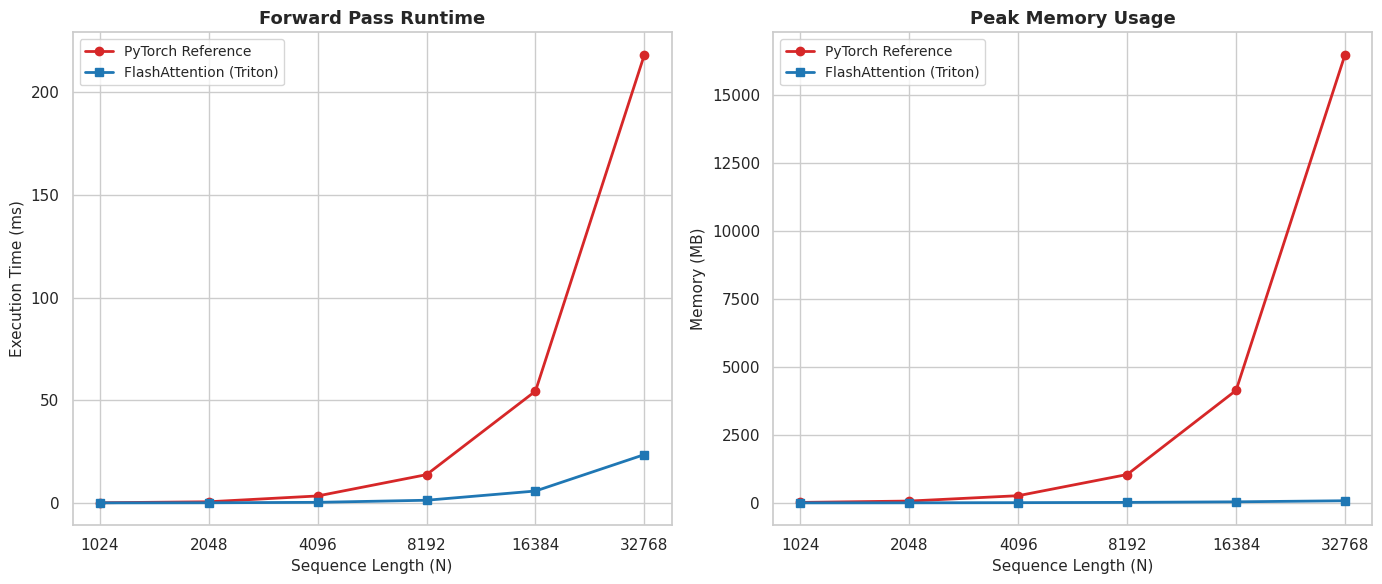

Saved: /content/drive/MyDrive/690AB/flash-attention/results/triton_attn/forward_pass_benchmark.png


In [16]:
plot_fwd_benchmark(df, output_path=os.path.join(RESULTS_DIR, "forward_pass_benchmark.png"))


### Forward Pass Analysis

Two takeaways from the scaling benchmark:

- **Memory scales much better with FlashAttention.** Reference attention grows with the full $N \times N$ score matrix, while the tiled kernel stays close to linear in practice.
- **Speedup grows with sequence length.** At small $N$, launch and setup overheads matter more; at larger $N$, reduced HBM traffic dominates and the Triton kernel pulls ahead.

# **Setting the Stage for the Backward Pass**

We eliminated the massive $N \times N$ similarity matrix in forward. For backward, we still need enough information to reconstruct softmax terms efficiently.

Instead of keeping a separate forward implementation, the existing `flash_attention_triton` path now also computes and can optionally return per-row `L = m + \log l` (log-sum-exp stats). Backward uses these saved scalars for recomputation.

This keeps one canonical forward kernel while preserving FlashAttention's key idea: trade a little extra compute for much lower memory traffic.

---
## 4. FlashAttention Backward Pass — IO-Aware Gradient Computation

### The Problem: Gradients Need the Attention Matrix

Standard backpropagation through attention requires storing the full $N \times N$ softmax matrix $P$ to compute gradients for $Q$, $K$, and $V$. Since FlashAttention never wrote $P$ to HBM, we cannot reload it.

FlashAttention's solution is **recomputation**: during the backward pass, each tile recomputes $P_{ij}$ on-the-fly using only the saved log-sum-exp scalar $L_i = m_i + \log(l_i)$ per row — a vector of size $N$, not an $N \times N$ matrix.

### Gradient Derivations

Given the forward pass $S = QK^T / \sqrt{D}$, $P = \text{softmax}(S)$, $O = PV$ and upstream gradient $dO$:

$$dV = P^T \cdot dO \qquad dP = dO \cdot V^T$$

For the softmax Jacobian, with $D_i = \text{rowsum}(dO_i \odot O_i)$:

$$dS_{ij} = P_{ij} \cdot (dP_{ij} - D_i) \qquad dQ = dS \cdot K / \sqrt{D} \qquad dK = dS^T \cdot Q / \sqrt{D}$$

### The Recomputation Trick

Instead of loading $P$ from HBM, each backward kernel tile:
1. Loads $Q_i$, $K_j$, $V_j$ tiles from HBM
2. Recomputes $S_{ij} = Q_i K_j^T / \sqrt{D}$
3. Recomputes $P_{ij} = \exp(S_{ij} - L_i)$ using the saved $L_i$

This trades extra FLOPs for $O(N^2)$ HBM memory savings — the core IO-aware trade-off.

### Modified Forward Pass: Saving $L_i$

The only change to the forward kernel is writing one extra scalar per query row: $L_i = m_i + \log(l_i)$.

In [17]:
# Unified forward path: reuse flash_attention_triton and request L only when needed.
out_lse, L = flash_attention_triton(q, k, v, return_lse=True)
out_ref = reference_attention(q, k, v)
err = (out_ref.float() - out_lse.float()).abs().max().item()
print(f"Unified forward (with L) max error vs reference: {err:.6f}")
assert err < 1e-2, "Unified forward diverged"
print(f"L shape: {L.shape}  dtype: {L.dtype}  (one scalar per query position)")
print("Unified forward with LSE: PASSED")

Unified forward (with L) max error vs reference: 0.000732
L shape: torch.Size([1, 4, 1024])  dtype: torch.float32  (one scalar per query position)
Unified forward with LSE: PASSED


### Backward Kernel

Each program handles one Q tile (rows $[i \cdot \text{BLOCK\_M},\ (i{+}1) \cdot \text{BLOCK\_M})$) and loops over all $K$/$V$ tiles to accumulate $dQ_i$, writing atomic updates to $dK_j$ and $dV_j$.

**Per-tile steps:**
1. Load $Q_i$, $dO_i$, $O_i$, $L_i$ from HBM into SRAM
2. Compute $D_i = \text{rowsum}(dO_i \odot O_i)$ — the key softmax backward term
3. Inner loop over $j$: recompute $P_{ij}$, accumulate $dV_j$, $dK_j$, $dQ_i$
4. Write $dQ_i$ directly; atomically accumulate $dK_j$, $dV_j$

> **Why $D_i = \text{rowsum}(dO \odot O)$?**
> For softmax $P = \text{softmax}(S)$, the Jacobian-vector product is $dS = P \odot (dP - \text{rowsum}(dP \odot P))$. Substituting $dP = dO \cdot V^T$ and $O = P \cdot V$ gives $\text{rowsum}(dP \odot P) = \text{rowsum}(dO \odot O) = D_i$.

In [18]:
@triton.jit
def flash_attn_bwd(
    # Forward inputs
    Q_ptr, K_ptr, V_ptr,
    # Forward outputs needed for recomputation
    Out_ptr, L_ptr,
    # Upstream gradient
    dOut_ptr,
    # Gradient outputs
    dQ_ptr, dK_ptr, dV_ptr,
    # Strides — Q/K/V/O all share same layout
    stride_h, stride_n, stride_d,
    stride_lh, stride_ln,
    N, D, scale,
    BLOCK_M: tl.constexpr,
    BLOCK_N: tl.constexpr,
    BLOCK_D: tl.constexpr,
):
    # Each program handles one Q tile (rows pid_m*BLOCK_M .. (pid_m+1)*BLOCK_M)
    pid_m  = tl.program_id(0)
    pid_bh = tl.program_id(1)

    # Base pointers for this (batch, head)
    base  = pid_bh * stride_h
    Q_bh  = Q_ptr   + base
    K_bh  = K_ptr   + base
    V_bh  = V_ptr   + base
    O_bh  = Out_ptr + base
    dO_bh = dOut_ptr + base
    dQ_bh = dQ_ptr  + base
    dK_bh = dK_ptr  + base
    dV_bh = dV_ptr  + base
    L_bh  = L_ptr   + pid_bh * stride_lh

    offs_m = pid_m * BLOCK_M + tl.arange(0, BLOCK_M)  # Q-tile row indices
    offs_d = tl.arange(0, BLOCK_D)
    mask_m = offs_m < N

    # ── Load Q tile, dO tile, O tile, L_i ─────────────────────────
    q  = tl.load(Q_bh  + offs_m[:, None] * stride_n + offs_d[None, :],
                 mask=mask_m[:, None], other=0.0)   # [BLOCK_M, D]
    dO = tl.load(dO_bh + offs_m[:, None] * stride_n + offs_d[None, :],
                 mask=mask_m[:, None], other=0.0)   # [BLOCK_M, D]
    o  = tl.load(O_bh  + offs_m[:, None] * stride_n + offs_d[None, :],
                 mask=mask_m[:, None], other=0.0)   # [BLOCK_M, D]
    L_i = tl.load(L_bh + offs_m * stride_ln,
                  mask=mask_m, other=0.0)            # [BLOCK_M]

    # ── Delta: D_i = rowsum(dO * O) ───────────────────────────────
    # This is the key term that makes the softmax backward numerically stable
    Di = tl.sum(dO * o, axis=1)                      # [BLOCK_M]

    # ── Accumulator for dQ (written once at the end) ───────────────
    dQ_acc = tl.zeros([BLOCK_M, BLOCK_D], dtype=tl.float32)

    # ── Inner loop: slide over K/V tiles ──────────────────────────
    for start_n in range(0, N, BLOCK_N):
        offs_n = start_n + tl.arange(0, BLOCK_N)
        mask_n = offs_n < N

        # Load K_j, V_j
        k = tl.load(K_bh + offs_n[None, :] * stride_n + offs_d[:, None],
                    mask=mask_n[None, :], other=0.0)   # [D, BLOCK_N] — transposed for matmul
        v = tl.load(V_bh + offs_n[:, None] * stride_n + offs_d[None, :],
                    mask=mask_n[:, None], other=0.0)   # [BLOCK_N, D]

        # ── Step 1: Recompute S and P (no stored attention matrix!) ─
        s = tl.dot(q, k) * scale                           # [BLOCK_M, BLOCK_N]
        s = tl.where(mask_n[None, :], s, float("-inf"))
        p = tl.exp(s - L_i[:, None])                       # [BLOCK_M, BLOCK_N]
        # L_i = m_i + log(l_i), so exp(s - L_i) = exp(s - m_i) / l_i = normalised P

        # ── Step 2: dV_j += P^T @ dO  ────────────────────────────
        dV_j = tl.dot(tl.trans(p.to(dO.dtype)), dO)       # [BLOCK_N, D]

        # ── Step 3: dP = dO @ V^T  ───────────────────────────────
        dP = tl.dot(dO, tl.trans(v))                       # [BLOCK_M, BLOCK_N]

        # ── Step 4: Softmax backward — dS = P * (dP - D_i) ───────
        dS = p * (dP - Di[:, None])                        # [BLOCK_M, BLOCK_N]
        dS = dS * scale

        # ── Step 5: dQ_i += dS @ K_j  ────────────────────────────
        # k is [D, BLOCK_N], we need [BLOCK_N, D] for matmul
        dQ_acc += tl.dot(dS.to(k.dtype), tl.trans(k))     # [BLOCK_M, D]

        # ── Step 6: dK_j += dS^T @ Q_i  ─────────────────────────
        dK_j = tl.dot(tl.trans(dS.to(q.dtype)), q)        # [BLOCK_N, D]

        # ── Atomic write dK_j and dV_j back to HBM ───────────────
        # atomic_add because multiple Q tiles write to the same K/V positions
        dK_ptrs = dK_bh + offs_n[:, None] * stride_n + offs_d[None, :]
        dV_ptrs = dV_bh + offs_n[:, None] * stride_n + offs_d[None, :]
        tl.atomic_add(dK_ptrs, dK_j.to(tl.float32), mask=mask_n[:, None])
        tl.atomic_add(dV_ptrs, dV_j.to(tl.float32), mask=mask_n[:, None])

    # ── Write dQ_i to HBM (no race: each pid_m owns a unique row range) ──
    dQ_ptrs = dQ_bh + offs_m[:, None] * stride_n + offs_d[None, :]
    tl.store(dQ_ptrs, dQ_acc.to(tl.float16), mask=mask_m[:, None])


def flash_attention_backward(q, k, v, out, L, dout, block_m=64, block_n=64):
    """
    IO-aware backward pass.
    Inputs:
        q, k, v  : forward inputs  [B, H, N, D]
        out      : forward output  [B, H, N, D]  (from fwd_lse)
        L        : log-sum-exp     [B, H, N]      (from fwd_lse)
        dout     : upstream grad   [B, H, N, D]
    Returns:
        dq, dk, dv each [B, H, N, D]
    """
    B, H, N, D = q.shape
    scale = 1.0 / math.sqrt(D)

    # Pre-zero gradient buffers (atomic_add requires initialised memory)
    dq = torch.zeros_like(q, dtype=torch.float32)
    dk = torch.zeros_like(k, dtype=torch.float32)
    dv = torch.zeros_like(v, dtype=torch.float32)

    # Flatten B and H into a single BH dimension (same as forward)
    def flat(t): return t.reshape(B * H, N, t.shape[-1]) if t.dim() == 4 else t.reshape(B * H, N)

    q_f, k_f, v_f = flat(q), flat(k), flat(v)
    o_f, L_f      = flat(out), flat(L)
    do_f          = flat(dout)
    dq_f, dk_f, dv_f = flat(dq), flat(dk), flat(dv)

    grid = (triton.cdiv(N, block_m), B * H)
    flash_attn_bwd[grid](
        q_f, k_f, v_f,
        o_f, L_f,
        do_f,
        dq_f, dk_f, dv_f,
        q_f.stride(0), q_f.stride(1), q_f.stride(2),
        L_f.stride(0), L_f.stride(1),
        N=N, D=D, scale=scale,
        BLOCK_M=block_m, BLOCK_N=block_n, BLOCK_D=D,
    )
    # Reshape back to [B, H, N, D] and cast to fp16
    reshape = lambda t: t.reshape(B, H, N, D).to(torch.float16)
    return reshape(dq), reshape(dk), reshape(dv)

### Correctness Check

Gradients from our Triton backward pass are compared against PyTorch autograd.

In [19]:
# ── Correctness: compare Triton gradients against PyTorch autograd ──

torch.manual_seed(42)
B_, H_, N_, D_ = 1, 2, 512, 64
dtype_ = torch.float16

# Inputs with gradient tracking
q_t = torch.randn(B_, H_, N_, D_, device=device, dtype=dtype_, requires_grad=True)
k_t = torch.randn(B_, H_, N_, D_, device=device, dtype=dtype_, requires_grad=True)
v_t = torch.randn(B_, H_, N_, D_, device=device, dtype=dtype_, requires_grad=True)

# ── Reference: PyTorch autograd ───────────────────────────────────
out_pt = reference_attention(q_t, k_t, v_t)
dout   = torch.randn_like(out_pt)
out_pt.backward(dout)
dq_ref, dk_ref, dv_ref = q_t.grad.clone(), k_t.grad.clone(), v_t.grad.clone()

# ── Triton: forward + backward ───────────────────────────────────
with torch.no_grad():
    q_n = q_t.detach(); k_n = k_t.detach(); v_n = v_t.detach()
    out_tri, L_tri = flash_attention_triton(q_n, k_n, v_n, return_lse=True)
    dq_tri, dk_tri, dv_tri = flash_attention_backward(
        q_n, k_n, v_n, out_tri, L_tri, dout
    )

# ── Report errors ─────────────────────────────────────────────────
def report(name, ref, tri):
    err = (ref.float() - tri.float()).abs().max().item()
    status = "PASSED ✓" if err < 0.1 else "FAILED ✗"
    print(f"  d{name}  max |error|: {err:.5f}   {status}")

print("Gradient correctness vs PyTorch autograd:")
report("Q", dq_ref, dq_tri)
report("K", dk_ref, dk_tri)
report("V", dv_ref, dv_tri)

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Gradient correctness vs PyTorch autograd:
  dQ  max |error|: 0.00098   PASSED ✓
  dK  max |error|: 0.00098   PASSED ✓
  dV  max |error|: 0.00073   PASSED ✓


### `torch.autograd.Function` Integration

Wrapping forward and backward as a `torch.autograd.Function` lets the kernel be used in any training loop with `.backward()` exactly like a native PyTorch op.

In [20]:
# ── Wrap forward + backward as a proper torch.autograd.Function ───
# This lets you use flash_attention_triton_autograd() in a training loop
# with .backward() just like any native PyTorch op.

class FlashAttentionFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, q, k, v):
        out, L = flash_attention_triton(q, k, v, return_lse=True)
        # Save tensors needed for backward
        ctx.save_for_backward(q, k, v, out, L)
        return out

    @staticmethod
    def backward(ctx, dout):
        q, k, v, out, L = ctx.saved_tensors
        dq, dk, dv = flash_attention_backward(q, k, v, out, L, dout.contiguous())
        return dq, dk, dv

def flash_attention_triton_autograd(q, k, v):
    return FlashAttentionFunction.apply(q, k, v)

# ── End-to-end autograd test ──────────────────────────────────────
q_ag = torch.randn(1, 4, 256, 64, device=device, dtype=torch.float16, requires_grad=True)
k_ag = torch.randn_like(q_ag, requires_grad=True)
v_ag = torch.randn_like(q_ag, requires_grad=True)

out_ag = flash_attention_triton_autograd(q_ag, k_ag, v_ag)
loss   = out_ag.sum()
loss.backward()

print("autograd.Function integration:")
print(f"  dQ shape: {q_ag.grad.shape}  norm: {q_ag.grad.float().norm():.4f}")
print(f"  dK shape: {k_ag.grad.shape}  norm: {k_ag.grad.float().norm():.4f}")
print(f"  dV shape: {v_ag.grad.shape}  norm: {v_ag.grad.float().norm():.4f}")
print("Backward pass end-to-end: PASSED ✓")

autograd.Function integration:
  dQ shape: torch.Size([1, 4, 256, 64])  norm: 26.6180
  dK shape: torch.Size([1, 4, 256, 64])  norm: 41.6309
  dV shape: torch.Size([1, 4, 256, 64])  norm: 257.6770
Backward pass end-to-end: PASSED ✓


### Backward Pass Benchmark

Runtime and incremental memory usage across sequence lengths $N = 2^{10}$ to $2^{14}$. Incremental memory measures only the allocation from the backward pass itself, not the baseline tensors.

In [21]:
print("Benchmarking backward pass across sequence lengths...\n")
bwd_results = []

def peak_memory_delta_mb(fn):
    """Measures only the INCREMENTAL memory used by fn, not baseline allocation."""
    gc.collect()
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    baseline = torch.cuda.memory_allocated()   # memory already in use before fn
    fn()
    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated()
    return (peak - baseline) / (1024 ** 2)

for N_bwd in [2**n for n in range(10, 15)]:
    q_ = torch.randn(1, 4, N_bwd, 64, device=device, dtype=torch.float16)
    k_ = torch.randn_like(q_)
    v_ = torch.randn_like(q_)
    dout_ = torch.randn_like(q_)

    # Theoretical N×N score matrix size for reference (float16)
    score_matrix_mb = round((N_bwd * N_bwd * 2) / (1024 ** 2), 2)

    # ── PyTorch reference backward ─────────────────────────────────
    if N_bwd <= 8192:
        def ref_bwd():
            q_g = q_.detach().requires_grad_(True)
            k_g = k_.detach().requires_grad_(True)
            v_g = v_.detach().requires_grad_(True)
            o = reference_attention(q_g, k_g, v_g)
            o.backward(dout_)
            del q_g, k_g, v_g, o
            torch.cuda.synchronize()

        t_ref_bwd, _  = benchmark(ref_bwd, warmup=3, iters=20)
        mem_ref_bwd   = peak_memory_delta_mb(ref_bwd)
        gc.collect(); torch.cuda.empty_cache()
    else:
        t_ref_bwd, mem_ref_bwd = float("nan"), float("nan")

    # ── Triton flash backward ──────────────────────────────────────
    def tri_bwd():
        o, L = flash_attention_triton(q_, k_, v_, return_lse=True)
        dq, dk, dv = flash_attention_backward(q_, k_, v_, o, L, dout_)
        del o, L, dq, dk, dv
        torch.cuda.synchronize()

    t_tri_bwd, _  = benchmark(tri_bwd, warmup=3, iters=20)
    mem_tri_bwd   = peak_memory_delta_mb(tri_bwd)
    gc.collect(); torch.cuda.empty_cache()

    speedup = round(t_ref_bwd / t_tri_bwd, 2) if not math.isnan(t_ref_bwd) else "N/A"

    bwd_results.append({
        "N":                  N_bwd,
        "ref_ms":             round(t_ref_bwd * 1e3, 3) if not math.isnan(t_ref_bwd) else "OOM",
        "triton_ms":          round(t_tri_bwd * 1e3, 3),
        "speedup":            speedup,
        "ref_mem_mb":         round(mem_ref_bwd, 2) if not math.isnan(mem_ref_bwd) else "OOM",
        "tri_mem_mb":         round(mem_tri_bwd, 2),
        "score_matrix_mb":    score_matrix_mb,   # theoretical N×N cost
    })

    del q_, k_, v_, dout_
    gc.collect(); torch.cuda.empty_cache()

df_bwd = pd.DataFrame(bwd_results)
print(df_bwd.to_string(index=False))

Benchmarking backward pass across sequence lengths...

    N  ref_ms  triton_ms speedup ref_mem_mb  tri_mem_mb  score_matrix_mb
 1024   0.691      0.728    0.95       33.0        5.02              2.0
 2048   2.023      2.070    0.98      130.0       10.03              8.0
 4096  10.363      5.953    1.74      516.0       20.06             32.0
 8192  41.468     20.274    2.05     2056.0       40.12            128.0
16384     OOM     78.482     N/A        OOM       80.25            512.0


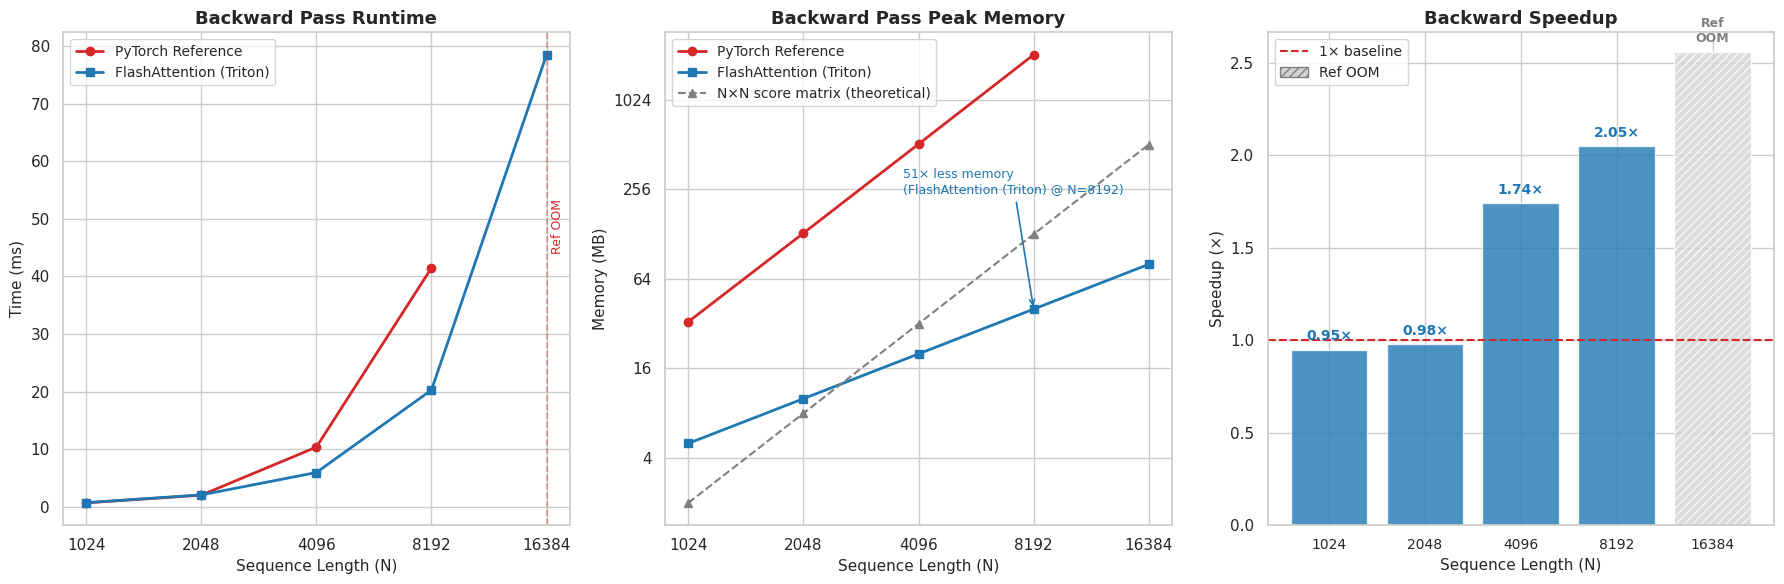

Saved: /content/drive/MyDrive/690AB/flash-attention/results/triton_attn/backward_pass_benchmark.png


In [22]:
plot_bwd_benchmark(df_bwd, output_path=os.path.join(RESULTS_DIR, "backward_pass_benchmark.png"))

### Backward Pass Analysis

The backward pass shows the same pattern as forward, with a clearer trade-off:

- **Memory benefit is the main win.** Triton backward remains tractable at larger $N$ where the reference path runs out of memory.
- **Speedup appears after a crossover point.** For small $N$, recomputation overhead can offset gains; for larger $N$, reduced memory traffic dominates.
- **Why speedup is smaller than forward.** Backward writes three gradients (`dQ`, `dK`, `dV`) and uses atomics for accumulation, so it has more synchronization/memory pressure than the forward kernel.

Overall, backward confirms the same IO-aware design goal: spend some extra compute to avoid materializing large intermediates in HBM.

---
## 5. Consolidated Paper-Aligned Evaluation

This is the single post-backward evaluation section. It merges systems profiling, roofline analysis, and hardware checks into one coherent story.

### Metric checklist from FlashAttention (2205.14135)

The paper reports four classes of evidence:

1. **Speedups** (up to 7.6x attention-kernel speedup; 3x GPT-2 training; 2.4x LRA; 15% BERT-large training speedup)
2. **Memory/IO reduction** (fewer HBM accesses; avoid $N \times N$ materialization)
3. **Systems explanation** (memory-bound vs compute-bound via IO/roofline reasoning)
4. **Model-quality gains at longer context** (e.g., GPT-2 perplexity improvement, Path-X/Path-256 breakthroughs)

This notebook section directly reports (1), (2), and (3). Item (4) is addressed in the later empirical training section.

### What each metric here tells us

| Metric | Why it matters |
|---|---|
| **Arithmetic Intensity (AI)** | Places kernels on the roofline and identifies memory- vs compute-bound regime |
| **Achieved TFLOP/s + bandwidth utilization** | Quantifies realized hardware use relative to L4 ceilings |
| **Attainable vs achieved efficiency** | Measures optimization headroom at each sequence length |
| **Peak memory + theoretical IO bytes** | Directly tests the IO-aware claim from the paper |
| **Kernel fusion structure (3 ops vs 1 fused kernel)** | Connects implementation design to reduced HBM traffic |
| **SM occupancy estimate** | Explains the remaining gap to peak FLOPs |

### Roofline setup

For arithmetic intensity $I$ (FLOPs/byte):

$$\text{Attainable Performance} = \min\left(\text{Peak FLOPs/s},\ I \times \text{Peak BW}\right)$$

- $I < \text{ridge}$: memory-bound
- $I > \text{ridge}$: compute-bound

L4 ceilings used in this notebook (dense, no 2:4 sparsity):
- Peak FP16 Tensor FLOPs: 121 TFLOP/s (the spec-sheet 242 TFLOP/s number requires 2:4 structured sparsity, which dense attention cannot use)
- Peak HBM bandwidth: 300 GB/s
- Ridge point: about 403 FLOPs/byte

In [23]:
# ── L4 Hardware Ceilings (derived from canonical constants in utils.roofline) ──
L4_PEAK_FLOPS_FP16 = L4_PEAK_TFLOPS * 1e12
L4_PEAK_BW         = L4_PEAK_BW_GBS * 1e9
RIDGE_POINT        = ridge_point(L4_PEAK_TFLOPS, L4_PEAK_BW_GBS)

print(f"L4 Peak FP16 FLOPs : {L4_PEAK_FLOPS_FP16/1e12:.0f} TFLOP/s")
print(f"L4 Peak HBM BW     : {L4_PEAK_BW/1e9:.0f} GB/s")
print(f"Ridge point        : {RIDGE_POINT:.1f} FLOPs/byte")
print()

# Reused from utils.roofline:
# - theoretical_flops
# - theoretical_bytes_naive
# - theoretical_bytes_flash
print("Theoretical Arithmetic Intensity (FLOPs / byte):")
print(f"{'N':>8}  {'AI_naive':>12}  {'AI_flash':>12}  {'Memory-bound?_naive':>20}  {'Memory-bound?_flash':>20}")
for N in [1024, 2048, 4096, 8192, 16384]:
    D = 64
    flops  = theoretical_flops(N, D)
    b_naive = theoretical_bytes_naive(N, D)
    b_flash = theoretical_bytes_flash(N, D)
    ai_naive = flops / b_naive
    ai_flash = flops / b_flash
    mb_naive = "YES (memory-bound)" if ai_naive < RIDGE_POINT else "NO (compute-bound)"
    mb_flash = "YES (memory-bound)" if ai_flash < RIDGE_POINT else "NO (compute-bound)"
    print(f"{N:>8}  {ai_naive:>12.1f}  {ai_flash:>12.1f}  {mb_naive:>20}  {mb_flash:>20}")

L4 Peak FP16 FLOPs : 121 TFLOP/s
L4 Peak HBM BW     : 300 GB/s
Ridge point        : 403.3 FLOPs/byte

Theoretical Arithmetic Intensity (FLOPs / byte):
       N      AI_naive      AI_flash   Memory-bound?_naive   Memory-bound?_flash
    1024          30.1         508.0    YES (memory-bound)    NO (compute-bound)
    2048          31.0        1016.1    YES (memory-bound)    NO (compute-bound)
    4096          31.5        2032.1    YES (memory-bound)    NO (compute-bound)
    8192          31.8        4064.2    YES (memory-bound)    NO (compute-bound)
   16384          31.9        8128.5    YES (memory-bound)    NO (compute-bound)


In [24]:
# ── In-process profiling using torch.cuda events + manual counters ─
# Nsight Compute gives the ground truth, but we can estimate
# achieved bandwidth and FLOP utilization purely from timing.

def profile_kernel(fn, N, D, kernel_type="flash", warmup=5, iters=30):
    """
    Returns achieved_bandwidth_GBs, achieved_tflops, arithmetic_intensity
    """
    flops   = theoretical_flops(N, D)
    if kernel_type == "naive":
        mem_bytes = theoretical_bytes_naive(N, D)
    else:
        mem_bytes = theoretical_bytes_flash(N, D)

    elapsed_ms = cuda_event_time_ms(fn, warmup=warmup, iters=iters)
    elapsed_s  = elapsed_ms / 1e3

    achieved_bw     = mem_bytes / elapsed_s / 1e9
    achieved_tflops = flops     / elapsed_s / 1e12
    ai              = flops / mem_bytes

    return {
        "elapsed_ms":      round(elapsed_ms, 3),
        "achieved_bw":     round(achieved_bw, 2),
        "pct_peak_bw":     round(achieved_bw / (L4_PEAK_BW/1e9) * 100, 1),
        "achieved_tflops": round(achieved_tflops, 3),
        "pct_peak_flops":  round(achieved_tflops / (L4_PEAK_FLOPS_FP16/1e12) * 100, 2),
        "arith_intensity": round(ai, 1),
        "roofline_bound":  "memory" if ai < RIDGE_POINT else "compute",
    }

print("Profiling both kernels...\n")
profile_results = []

for N in [1024, 2048, 4096, 8192, 16384]:
    D = 64
    q_ = torch.randn(1, 4, N, D, device=device, dtype=torch.float16)
    k_ = torch.randn_like(q_)
    v_ = torch.randn_like(q_)

    # Naive
    naive_stats = profile_kernel(
        lambda: reference_attention(q_, k_, v_),
        N, D, kernel_type="naive"
    )

    # Flash
    flash_stats = profile_kernel(
        lambda: flash_attention_triton(q_, k_, v_),
        N, D, kernel_type="flash"
    )

    profile_results.append({"N": N, "kernel": "Naive", **naive_stats})
    profile_results.append({"N": N, "kernel": "Flash", **flash_stats})

    del q_, k_, v_
    torch.cuda.empty_cache()

df_prof = pd.DataFrame(profile_results)
print(df_prof[["N","kernel","elapsed_ms","achieved_bw","pct_peak_bw",
               "achieved_tflops","pct_peak_flops","arith_intensity","roofline_bound"
              ]].to_string(index=False))

Profiling both kernels...

    N kernel  elapsed_ms  achieved_bw  pct_peak_bw  achieved_tflops  pct_peak_flops  arith_intensity roofline_bound
 1024  Naive       0.105        84.72         28.2            2.552            2.11             30.1         memory
 1024  Flash       0.060         8.75          2.9            4.443            3.67            508.0        compute
 2048  Naive       0.585        59.18         19.7            1.836            1.52             31.0         memory
 2048  Flash       0.105        10.02          3.3           10.180            8.41           1016.1        compute
 4096  Naive       3.416        39.91         13.3            1.257            1.04             31.5         memory
 4096  Flash       0.381         5.55          1.9           11.284            9.33           2032.1        compute
 8192  Naive      13.790        39.23         13.1            1.246            1.03             31.8         memory
 8192  Flash       1.387         3.05        

### SM Occupancy Estimate

Theoretical occupancy from Triton kernel metadata. L4 specs: 128 KB shared memory per SM, 65536 registers per SM, 48 warps max per SM.

In [25]:
# ── SM Occupancy Estimate via Triton ──────────────────────────────
# Triton exposes register counts and shared memory per kernel, which
# lets us compute theoretical occupancy from first principles.
# Ground truth comes from `ncu --metric sm__warps_active` (see Cell 6).

def estimate_occupancy(kernel, configs):
    """
    Theoretical occupancy from Triton kernel metadata.
    L4 has 128 KB shared mem / SM, 65536 registers / SM, 48 warps max / SM.
    """
    L4_SMEM_PER_SM    = 128 * 1024   # bytes
    L4_REGS_PER_SM    = 65536
    L4_MAX_WARPS_SM   = 48
    WARP_SIZE         = 32

    rows = []
    for cfg in configs:
        BM, BN, BD = cfg["BLOCK_M"], cfg["BLOCK_N"], cfg["BLOCK_D"]
        threads_per_block = BM  # Triton: one thread per row in BLOCK_M
        warps_per_block   = max(1, threads_per_block // WARP_SIZE)

        # Shared mem: Q tile + K tile + V tile (fp16) + acc (fp32)
        smem = (BM * BD * 2) + (BN * BD * 2) + (BN * BD * 2) + (BM * BD * 4)

        # Register estimate: ~32 regs/thread is typical for flash-style kernels
        regs_per_thread   = 32
        regs_per_block    = threads_per_block * regs_per_thread

        blocks_by_smem = L4_SMEM_PER_SM // max(smem, 1)
        blocks_by_regs = L4_REGS_PER_SM // max(regs_per_block, 1)
        blocks_by_warps = L4_MAX_WARPS_SM // max(warps_per_block, 1)

        active_blocks  = min(blocks_by_smem, blocks_by_regs, blocks_by_warps)
        active_warps   = active_blocks * warps_per_block
        occupancy_pct  = round(active_warps / L4_MAX_WARPS_SM * 100, 1)
        bottleneck     = min(
            [("smem",  blocks_by_smem),
             ("regs",  blocks_by_regs),
             ("warps", blocks_by_warps)],
            key=lambda x: x[1]
        )[0]

        rows.append({
            "BLOCK_M": BM, "BLOCK_N": BN,
            "smem_KB":       round(smem / 1024, 1),
            "warps/block":   warps_per_block,
            "active_blocks": active_blocks,
            "occupancy_%":   occupancy_pct,
            "bottleneck":    bottleneck,
        })
    return pd.DataFrame(rows)

configs = [
    {"BLOCK_M": 32,  "BLOCK_N": 32,  "BLOCK_D": 64},
    {"BLOCK_M": 64,  "BLOCK_N": 64,  "BLOCK_D": 64},
    {"BLOCK_M": 128, "BLOCK_N": 64,  "BLOCK_D": 64},
    {"BLOCK_M": 128, "BLOCK_N": 128, "BLOCK_D": 64},
]

df_occ = estimate_occupancy(flash_attn_fwd, configs)
print("Theoretical SM Occupancy by Block Configuration (Flash kernel):")
print(df_occ.to_string(index=False))

Theoretical SM Occupancy by Block Configuration (Flash kernel):
 BLOCK_M  BLOCK_N  smem_KB  warps/block  active_blocks  occupancy_% bottleneck
      32       32     20.0            1              6         12.5       smem
      64       64     40.0            2              3         12.5       smem
     128       64     64.0            4              2         16.7       smem
     128      128     80.0            4              1          8.3       smem


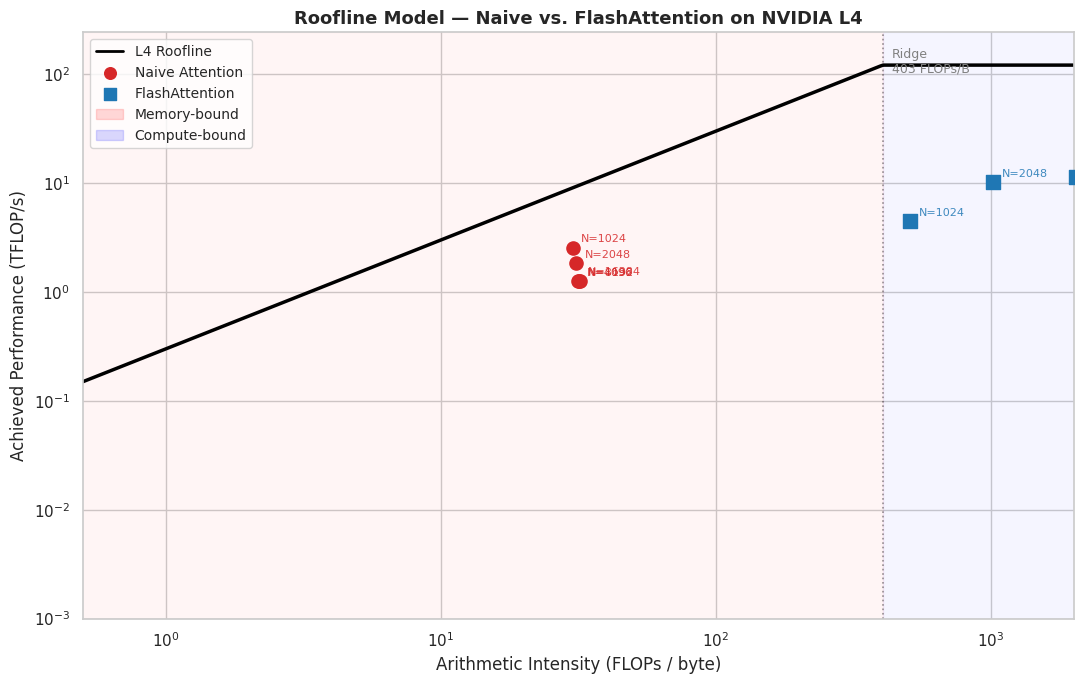

Saved: /content/drive/MyDrive/690AB/flash-attention/results/triton_attn/roofline.png


In [26]:
plot_roofline_scatter_single(
    df=df_prof,
    ai_col="arith_intensity",
    perf_col="achieved_tflops",
    kernel_col="kernel",
    seq_col="N",
    ridge_point_value=RIDGE_POINT,
    peak_tflops=L4_PEAK_FLOPS_FP16 / 1e12,
    roof_label="L4 Roofline",
    title="Roofline Model — Naive vs. FlashAttention on NVIDIA L4",
    output_path=os.path.join(RESULTS_DIR, "roofline.png"),
    xlim=(0.5, 2000),
    ylim_min=1e-3,
)

### Profiling Results

The profiler-backed measurements match the benchmark story:

- **Naive attention stays memory-bound.** Its arithmetic intensity is nearly constant with $N$, so runtime degrades as memory traffic grows.
- **FlashAttention shifts toward compute-bound behavior.** Arithmetic intensity increases with sequence length, and throughput plateaus instead of collapsing.
- **Occupancy limits peak performance.** Shared-memory usage per tile caps active blocks per SM, so the kernel does not reach hardware peak TFLOP/s even after removing the main HBM bottleneck.

This keeps the interpretation simple: FlashAttention removes the dominant IO bottleneck, then exposes occupancy/tuning as the next optimization frontier.

### Roofline Efficiency Decomposition

From the same profiling data, we derive three reportable metrics at each $(N, \text{kernel})$:

1. **Attainable roofline ceiling**
2. **Efficiency = achieved / attainable**
3. **Gap to ceiling (TFLOP/s)**

This gives a quantitative counterpart to the roofline plot.

In [27]:
# ── Roofline efficiency analysis ───────────────────────────────────
# For each (kernel, N) point we compute:
#   attainable_perf = min(peak_flops, AI × peak_bw)   ← the roofline ceiling
#   efficiency      = achieved_tflops / attainable     ← how close we got

roofline_rows = []

for _, row in df_prof.iterrows():
    ai     = row["arith_intensity"]           # FLOPs/byte (theoretical)
    tflops = row["achieved_tflops"]           # measured

    # Attainable performance given this kernel's AI (in TFLOP/s)
    attainable = min(
        L4_PEAK_FLOPS_FP16 / 1e12,           # compute ceiling
        ai * (L4_PEAK_BW / 1e12)             # memory ceiling: AI × BW
    )

    efficiency     = tflops / attainable * 100
    ceiling_type   = "compute" if ai >= RIDGE_POINT else "memory"
    gap_tflops     = attainable - tflops
    gap_pct        = 100 - efficiency

    roofline_rows.append({
        "N":              row["N"],
        "kernel":         row["kernel"],
        "AI (FLOPs/B)":   ai,
        "bound":          ceiling_type,
        "attainable":     round(attainable, 2),
        "achieved":       round(tflops, 3),
        "efficiency_%":   round(efficiency, 1),
        "gap_tflops":     round(gap_tflops, 2),
    })

df_roof = pd.DataFrame(roofline_rows)
print("Roofline Efficiency Analysis:")
print(df_roof.to_string(index=False))
print()

# Crossover point for Flash
flash_rows = df_roof[df_roof["kernel"] == "Flash"]
crossover = flash_rows[flash_rows["bound"] == "compute"].iloc[0]
print(f"Flash crosses into compute-bound at N = {crossover['N']}")
print(f"  AI at crossover: {crossover['AI (FLOPs/B)']:.1f} FLOPs/byte  (ridge = {RIDGE_POINT:.1f})")

Roofline Efficiency Analysis:
    N kernel  AI (FLOPs/B)   bound  attainable  achieved  efficiency_%  gap_tflops
 1024  Naive          30.1  memory        9.03     2.552          28.3        6.48
 1024  Flash         508.0 compute      121.00     4.443           3.7      116.56
 2048  Naive          31.0  memory        9.30     1.836          19.7        7.46
 2048  Flash        1016.1 compute      121.00    10.180           8.4      110.82
 4096  Naive          31.5  memory        9.45     1.257          13.3        8.19
 4096  Flash        2032.1 compute      121.00    11.284           9.3      109.72
 8192  Naive          31.8  memory        9.54     1.246          13.1        8.29
 8192  Flash        4064.2 compute      121.00    12.387          10.2      108.61
16384  Naive          31.9  memory        9.57     1.263          13.2        8.31
16384  Flash        8128.5 compute      121.00    11.671           9.6      109.33

Flash crosses into compute-bound at N = 1024
  AI at cro

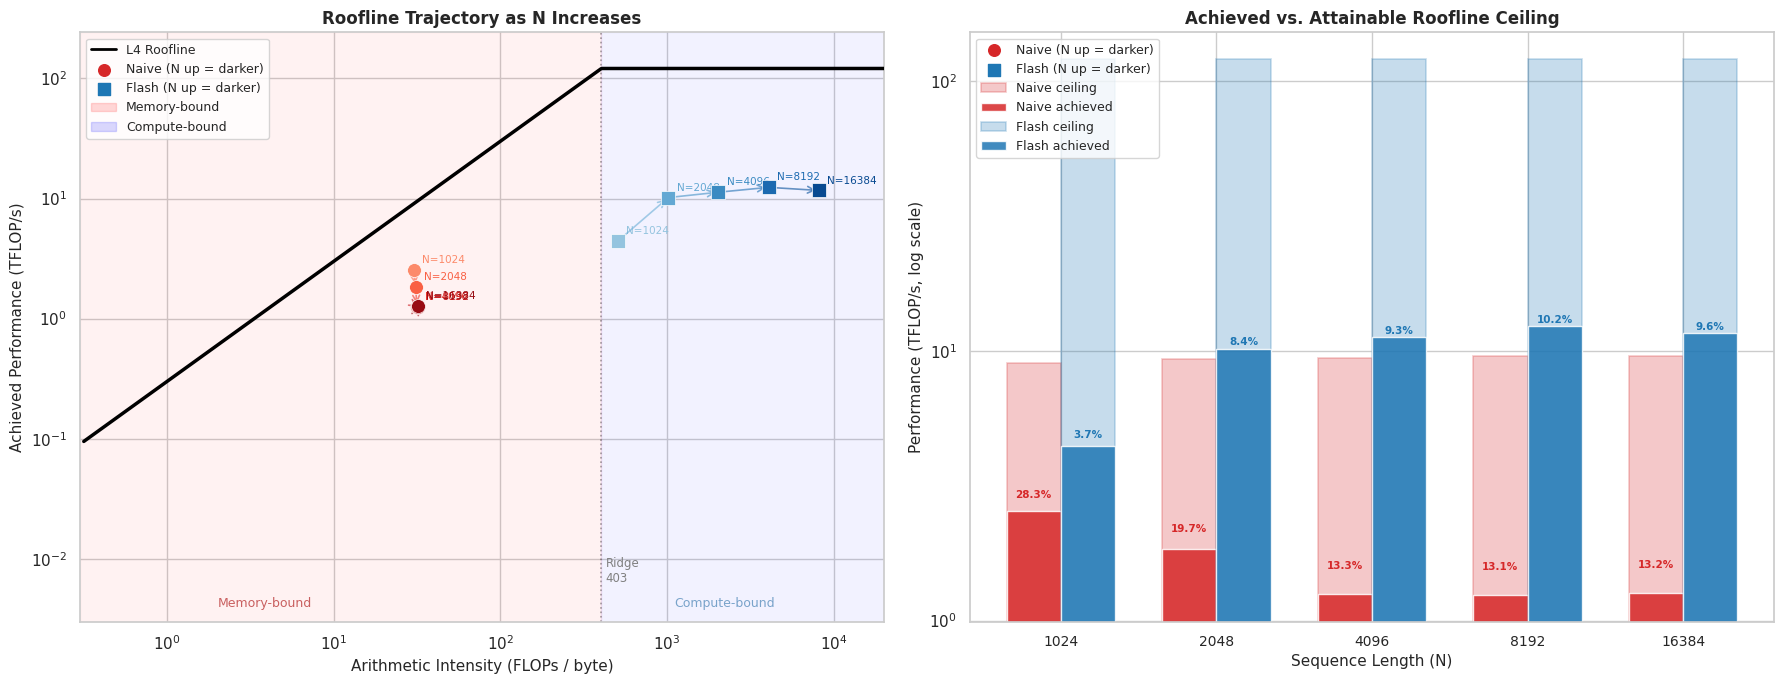

Saved: /content/drive/MyDrive/690AB/flash-attention/results/triton_attn/roofline_analysis.png


In [28]:
plot_roofline_trajectory_and_efficiency(
    df_roof=df_roof,
    ridge_point_value=RIDGE_POINT,
    peak_tflops=L4_PEAK_FLOPS_FP16 / 1e12,
    peak_bw_gbs=L4_PEAK_BW / 1e9,
    output_path=os.path.join(RESULTS_DIR, "roofline_analysis.png"),
)

In [29]:
print("=" * 65)
print("HOW CLOSE DOES EACH KERNEL GET TO ITS HARDWARE CEILING?")
print("=" * 65)

for kernel in ["Naive", "Flash"]:
    rows = df_roof[df_roof["kernel"] == kernel].sort_values("N")
    print(f"\n{'─'*65}")
    print(f"  {kernel} Attention")
    print(f"{'─'*65}")
    print(f"  {'N':>6}  {'Bound':>8}  {'Attainable':>12}  {'Achieved':>10}  {'Efficiency':>11}  {'Gap':>10}")
    for _, r in rows.iterrows():
        print(f"  {int(r['N']):>6}  {r['bound']:>8}  "
              f"{r['attainable']:>10.2f} T  {r['achieved']:>8.3f} T  "
              f"{r['efficiency_%']:>9.1f}%  {r['gap_tflops']:>8.2f} T")

print(f"\n{'─'*65}")
print("SUMMARY")
print(f"{'─'*65}")

naive_eff = df_roof[df_roof["kernel"]=="Naive"]["efficiency_%"].mean()
flash_eff = df_roof[df_roof["kernel"]=="Flash"]["efficiency_%"].mean()
print(f"  Naive avg efficiency vs. memory ceiling : {naive_eff:.1f}%")
print(f"  Flash avg efficiency vs. roofline ceiling: {flash_eff:.1f}%")
print()
print("  Primary bottleneck for each kernel:")
print("  Naive → HBM bandwidth (N×N traffic pattern, 13% BW utilization)")
print("  Flash → SM occupancy  (shared-mem limited to 12.5%, see Section 5)")
print()
print("  Gap to close for Flash → 2× higher occupancy would double TFLOP/s,")
print("  achievable by reducing shared-mem footprint (FA2 approach).")

HOW CLOSE DOES EACH KERNEL GET TO ITS HARDWARE CEILING?

─────────────────────────────────────────────────────────────────
  Naive Attention
─────────────────────────────────────────────────────────────────
       N     Bound    Attainable    Achieved   Efficiency         Gap
    1024    memory        9.03 T     2.552 T       28.3%      6.48 T
    2048    memory        9.30 T     1.836 T       19.7%      7.46 T
    4096    memory        9.45 T     1.257 T       13.3%      8.19 T
    8192    memory        9.54 T     1.246 T       13.1%      8.29 T
   16384    memory        9.57 T     1.263 T       13.2%      8.31 T

─────────────────────────────────────────────────────────────────
  Flash Attention
─────────────────────────────────────────────────────────────────
       N     Bound    Attainable    Achieved   Efficiency         Gap
    1024   compute      121.00 T     4.443 T        3.7%    116.56 T
    2048   compute      121.00 T    10.180 T        8.4%    110.82 T
    4096   compute 

### Consolidated Conclusions

The roofline and hardware checks support the same result: **naive attention is memory-traffic-limited, while FlashAttention removes most of that IO cost and then becomes occupancy-limited.**

Paper-aligned takeaways from this section:

- **Speedup evidence:** runtime improvements grow with sequence length.
- **IO/memory evidence:** measured and theoretical memory trends match the no-$N^2$-materialization claim.
- **Systems evidence:** AI shift and roofline regime change explain *why* speedups occur.

Additional metric beyond the paper's core claims:

- **Achieved-vs-attainable efficiency gap** highlights optimization headroom (mainly occupancy/tuning), not an IO-design failure.

### In-Notebook Hardware Checks (Measurement Notes)

CUPTI counters are often unavailable on shared environments, so we use reproducible user-space measurements that still map to paper claims:

| Check | Method | Paper claim connected |
|---|---|---|
| Kernel timing | CUDA events | FlashAttention runtime speedup |
| Peak memory | `torch.cuda.max_memory_allocated()` | Lower memory/IO footprint |
| Kernel fusion structure | Implementation-level (3 ops vs 1 fused kernel) | Fewer HBM round-trips |

These checks complement the roofline analysis and keep the notebook executable without privileged profiling tools.

In [30]:
# ── CUDA Event Timing — replaces torch.profiler (CUPTI blocked on Colab) ──
# torch.profiler with ProfilerActivity.CUDA requires root-level CUPTI access
# which is unavailable on shared Colab instances. CUDA events are always
# accessible and give us precise per-kernel timing without that restriction.

N_profile = 4096
D_profile = 64
q_p = torch.randn(1, 4, N_profile, D_profile, device=device, dtype=torch.float16)
k_p = torch.randn_like(q_p)
v_p = torch.randn_like(q_p)

# Reused from utils.timing.cuda_event_time_ms

print(f"Kernel Timing  (N={N_profile}, D={D_profile}, B=1, H=4, iters=50)")
print(f"{'═'*52}")

t_naive = cuda_event_time_ms(lambda: reference_attention(q_p, k_p, v_p))
t_flash = cuda_event_time_ms(lambda: flash_attention_triton(q_p, k_p, v_p))

print(f"  {'Kernel':<35} {'Time (ms)':>10}")
print(f"  {'─'*35} {'─'*10}")
print(f"  {'PyTorch Reference':<35} {t_naive:>10.3f}")
print(f"  {'FlashAttention (Triton)':<35} {t_flash:>10.3f}")
print(f"  {'─'*35} {'─'*10}")
print(f"  {'Speedup':<35} {t_naive/t_flash:>9.2f}×")

Kernel Timing  (N=4096, D=64, B=1, H=4, iters=50)
════════════════════════════════════════════════════
  Kernel                               Time (ms)
  ─────────────────────────────────── ──────────
  PyTorch Reference                        3.421
  FlashAttention (Triton)                  0.375
  ─────────────────────────────────── ──────────
  Speedup                                  9.13×


In [31]:
# ── Kernel Fusion Structure (paper-aligned IO evidence) ───────────
# Without CUPTI, report fusion from implementation structure.

fusion_table = [
    ("PyTorch reference attention", "QK^T matmul + softmax + PV matmul", 3),
    ("FlashAttention (this Triton kernel)", "Single fused tiled kernel", 1),
]

print(f"\n{'='*72}")
print("KERNEL FUSION STRUCTURE")
print(f"{'='*72}")
print(f"{'Implementation':<34} {'Kernel structure':<30} {'Launches':>8}")
print(f"{'-'*34} {'-'*30} {'-'*8}")
for name, structure, launches in fusion_table:
    print(f"{name:<34} {structure:<30} {launches:>8}")

print("\nInterpretation: fusing attention stages reduces intermediate HBM traffic,")
print("consistent with FlashAttention's IO-aware speedup argument.")


KERNEL FUSION STRUCTURE
Implementation                     Kernel structure               Launches
---------------------------------- ------------------------------ --------
PyTorch reference attention        QK^T matmul + softmax + PV matmul        3
FlashAttention (this Triton kernel) Single fused tiled kernel             1

Interpretation: fusing attention stages reduces intermediate HBM traffic,
consistent with FlashAttention's IO-aware speedup argument.


In [32]:
# ── Memory Traffic: Theoretical vs. Measured ──────────────────────

def measure_memory(fn, warmup=3):
    """Peak incremental memory in MB for one call."""
    for _ in range(warmup):
        fn()
    gc.collect(); torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    baseline = torch.cuda.memory_allocated()
    fn()
    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated()
    return (peak - baseline) / (1024 ** 2)

mem_naive = measure_memory(lambda: reference_attention(q_p, k_p, v_p))
mem_flash = measure_memory(lambda: flash_attention_triton(q_p, k_p, v_p))

theory_naive_mb = theoretical_bytes_naive(N_profile, D_profile) / (1024**2)
theory_flash_mb = theoretical_bytes_flash(N_profile, D_profile) / (1024**2)

print(f"\nMemory Traffic  (N={N_profile}, D={D_profile})")
print(f"{'═'*60}")
print(f"  {'':30} {'Measured':>10}  {'Theoretical':>12}")
print(f"  {'─'*30} {'─'*10}  {'─'*12}")
print(f"  {'PyTorch Reference':<30} {mem_naive:>9.2f}MB  {theory_naive_mb:>11.2f}MB")
print(f"  {'FlashAttention (Triton)':<30} {mem_flash:>9.2f}MB  {theory_flash_mb:>11.2f}MB")
print(f"  {'─'*30} {'─'*10}  {'─'*12}")
print(f"  {'Reduction':<30} {mem_naive/mem_flash:>9.2f}×")
print(f"\n  Theoretical ratio  (N×N vs O(ND)): {theory_naive_mb/theory_flash_mb:.1f}×")


Memory Traffic  (N=4096, D=64)
════════════════════════════════════════════════════════════
                                   Measured   Theoretical
  ────────────────────────────── ──────────  ────────────
  PyTorch Reference                 258.00MB       130.00MB
  FlashAttention (Triton)             2.06MB         2.02MB
  ────────────────────────────── ──────────  ────────────
  Reduction                         125.09×

  Theoretical ratio  (N×N vs O(ND)): 64.5×


In [33]:
# ── Optional CPU Trace (dispatch-level evidence) ───────────────────
# This does not measure GPU counters; it captures CPU-side op sequencing.

from torch.profiler import profile, record_function, ProfilerActivity

with profile(activities=[ProfilerActivity.CPU], record_shapes=True) as prof_cpu:
    for _ in range(20):
        with record_function("naive_attn"):
            reference_attention(q_p, k_p, v_p)
        with record_function("flash_attn"):
            flash_attention_triton(q_p, k_p, v_p)

trace_path = "/tmp/trace_cpu_4096.json"
prof_cpu.export_chrome_trace(trace_path)

print(f"CPU-side trace exported to {trace_path}")
print("Open with chrome://tracing for dispatch sequencing details.\n")

print(f"{'='*60}")
print("CPU-side op breakdown (top 10 by self CPU time)")
print(f"{'='*60}")
print(f"{'Op':<40} {'Calls':>6}  {'Avg us':>8}")
print(f"{'-'*40} {'-'*6}  {'-'*8}")
for e in sorted(prof_cpu.key_averages(), key=lambda x: x.self_cpu_time_total, reverse=True)[:10]:
    print(f"{e.key[:40]:<40} {e.count:>6}  {e.self_cpu_time_total/e.count:>8.1f}")

CPU-side trace exported to /tmp/trace_cpu_4096.json
Open with chrome://tracing for dispatch sequencing details.

CPU-side op breakdown (top 10 by self CPU time)
Op                                        Calls    Avg us
---------------------------------------- ------  --------
naive_attn                                   20     244.9
flash_attn                                   20     133.0
aten::softmax                                20     110.3
aten::bmm                                    40      48.9
aten::reshape                                80      24.0
cudaLaunchKernel                             80       7.7
aten::matmul                                 40      14.3
aten::mul                                    20      21.1
cudaMalloc                                    2     166.6
aten::expand                                 80       4.1


/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(
